<h1>Macro Data</h1>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option('display.max_columns', None)

In [7]:
data_path = os.path.join("..", 'data')
macro_raw = pd.read_csv(os.path.join(data_path, 'macro_data.csv'), index_col=0)

In [8]:
macro_raw.head()

,industrial_production,real_person_income,unemployment_rate,initial_jobless_claims,cpi,oil_price,vix,credit_spread,yield_curve_slope,fed_funds_rate,consumer_sentiment,housing_starts,m2_money_supply
1990-01-31,61.7290,7184.9,5.4,345000.0,127.5,22.69,25.36,1.68,0.15,8.23,93.0,1551.0,3166.8
1990-02-28,62.2896,7210.5,5.3,350000.0,128.0,21.55,21.99,1.68,0.08,8.24,89.5,1437.0,3179.2
1990-03-31,62.5999,7216.8,5.2,346000.0,128.6,20.34,19.73,1.58,0.01,8.28,91.3,1289.0,3190.1
1990-04-30,62.4359,7262.7,5.4,363000.0,128.9,18.50,19.52,1.50,0.08,8.26,93.9,1248.0,3201.6
1990-05-31,62.6258,7252.9,5.4,359000.0,129.1,17.47,17.37,1.71,0.10,8.18,90.6,1212.0,3200.6


In [9]:
df = macro_raw.copy()

In [10]:
def adf_kpss_verdict(series: pd.Series, regression="c", alpha=0.05) -> dict:
    """Return both p-values and a joint verdict.

    regression='c' tests stationarity around a constant (no deterministic
    trend); use regression='ct' if you suspect a trend-stationary series.
    """
    s = series.dropna()
    adf_p  = adfuller(s, autolag="AIC")[1]
    kpss_p = kpss(s, regression=regression, nlags="auto")[1]

    if adf_p < alpha and kpss_p > alpha:
        verdict = "stationary"
    elif adf_p >= alpha and kpss_p <= alpha:
        verdict = "unit root"
    else:
        verdict = "inconclusive"
    return {"ADF p": adf_p, "KPSS p": kpss_p, "verdict": verdict}


level_results = pd.DataFrame(
    {code: adf_kpss_verdict(df[code]) for code in df.columns}
).T.round(4)
print("\nLevel-series stationarity tests")
print(level_results)


Level-series stationarity tests
                           ADF p    KPSS p       verdict
industrial_production   0.260809      0.01     unit root
real_person_income      0.990052      0.01     unit root
unemployment_rate       0.072481       0.1  inconclusive
initial_jobless_claims       0.0       0.1    stationary
cpi                     0.997855      0.01     unit root
oil_price               0.120168      0.01     unit root
vix                     0.003496       0.1    stationary
credit_spread           0.004411  0.059955    stationary
yield_curve_slope       0.007215       0.1    stationary
fed_funds_rate          0.011643      0.01  inconclusive
consumer_sentiment      0.423366      0.01     unit root
housing_starts          0.543466  0.065402  inconclusive
m2_money_supply         0.996113      0.01     unit root


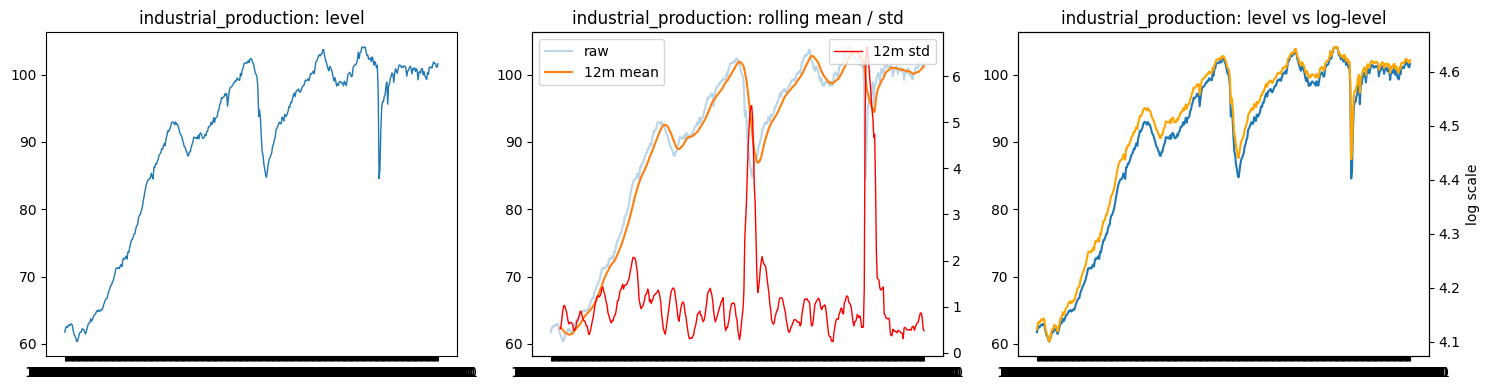

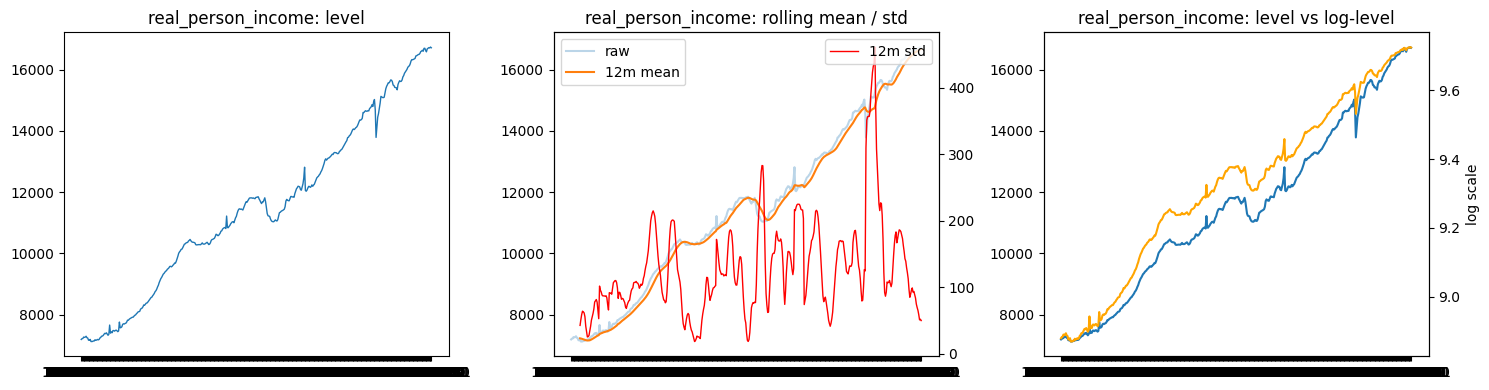

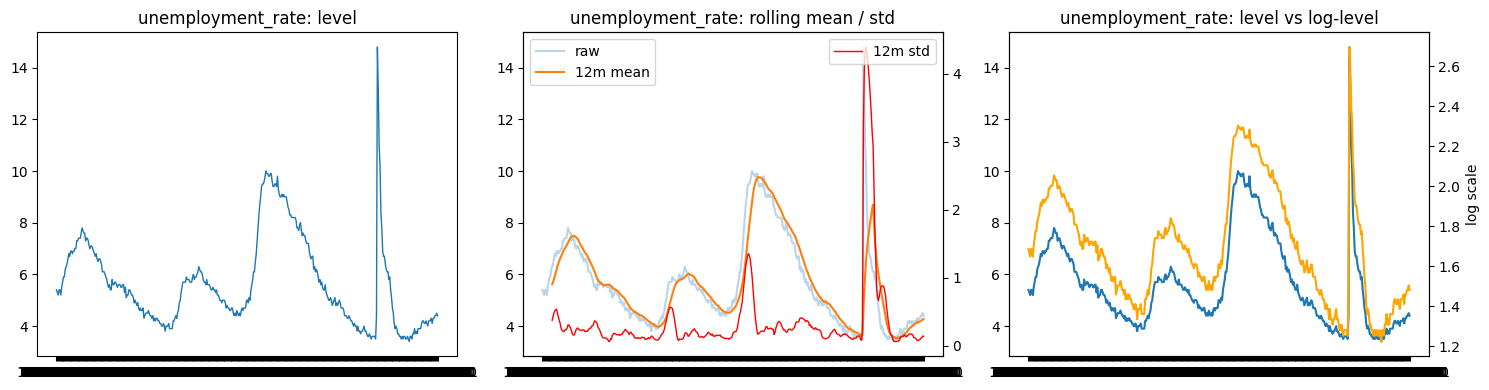

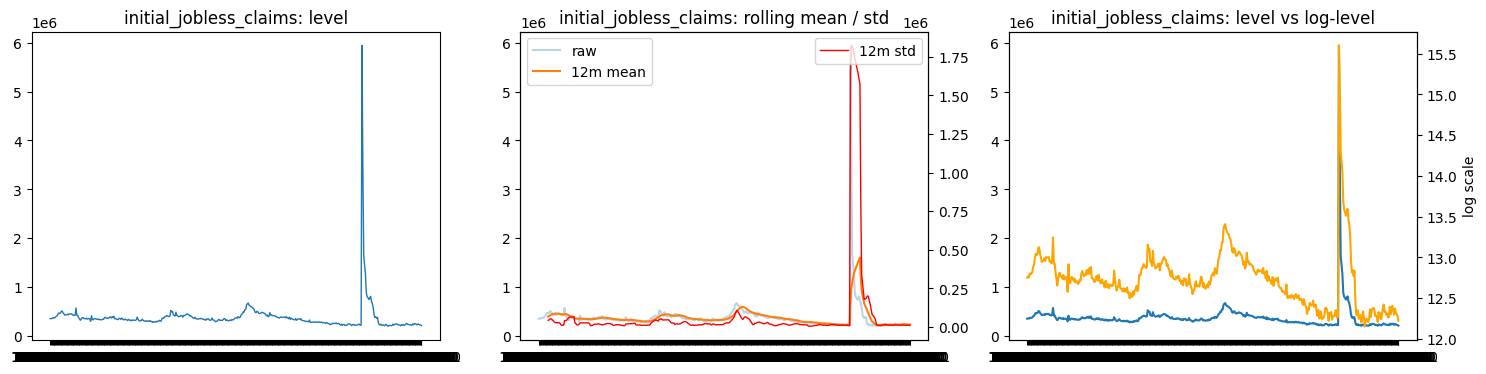

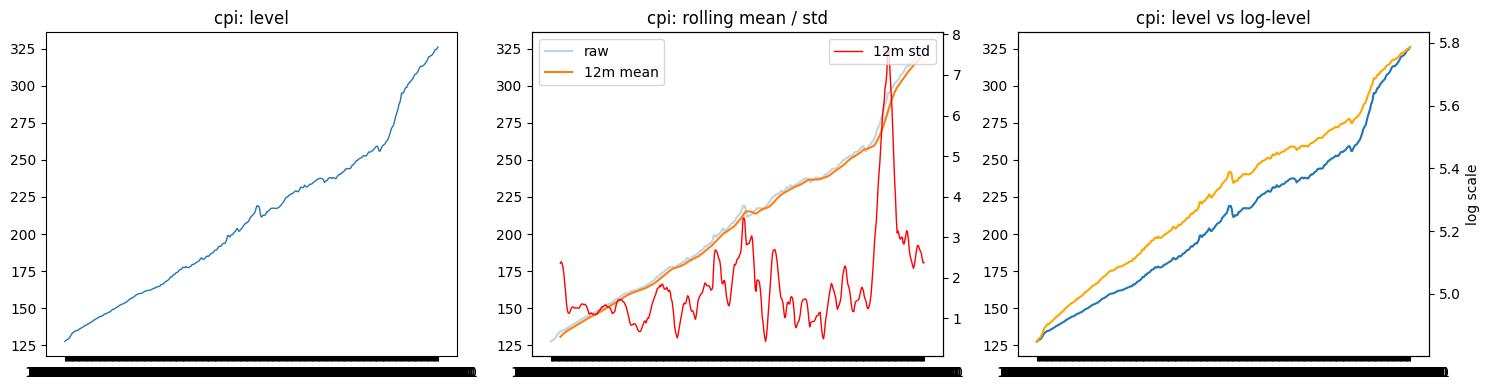

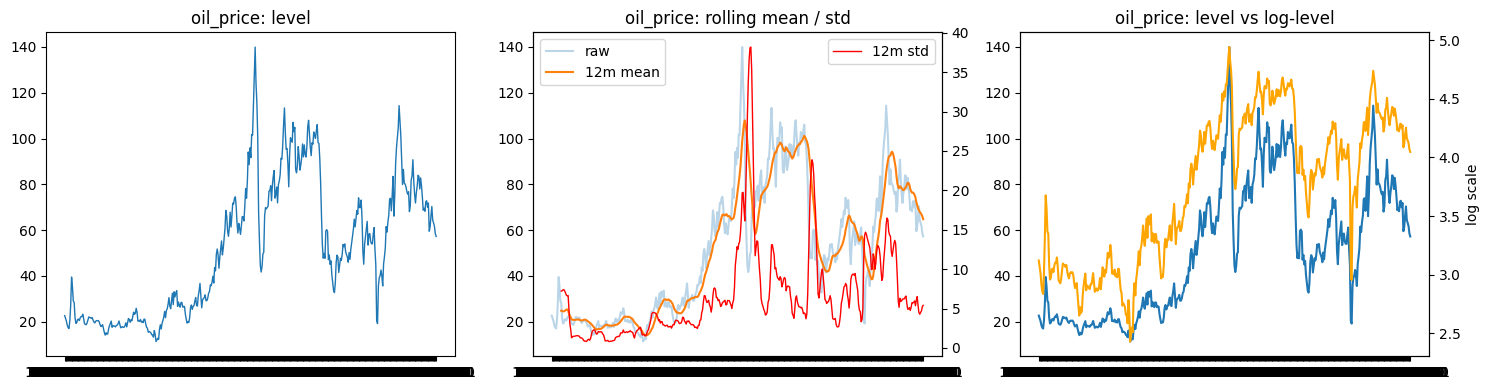

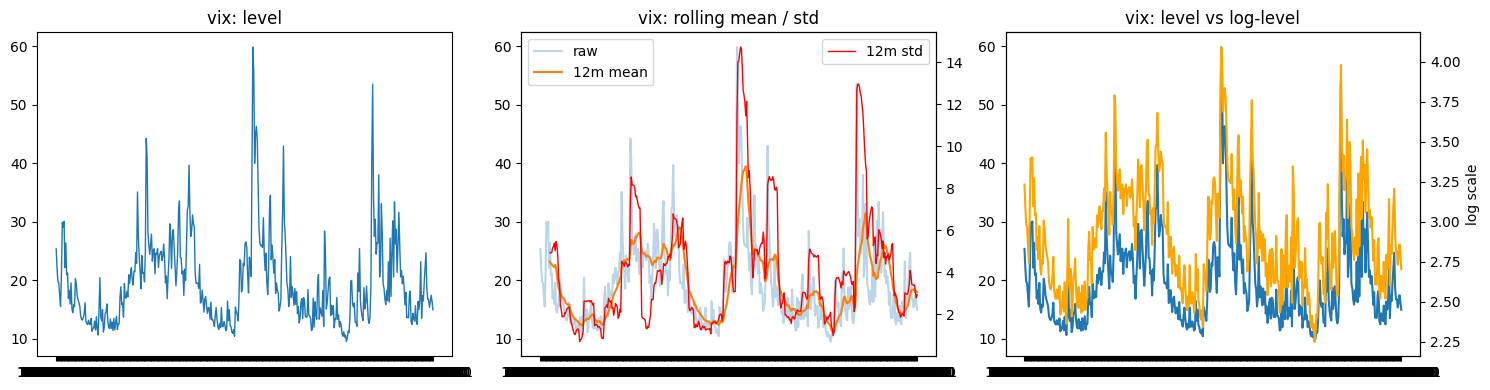

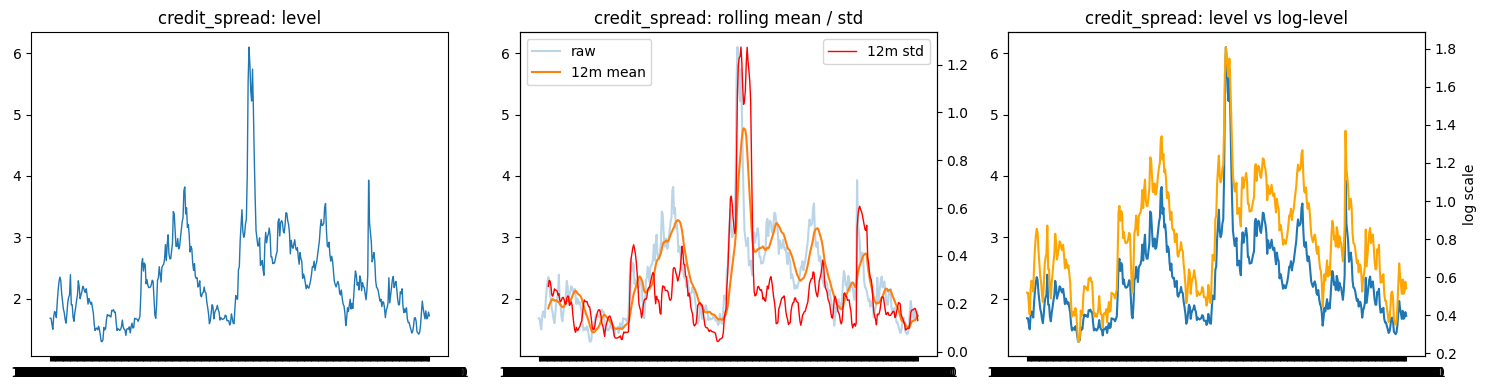

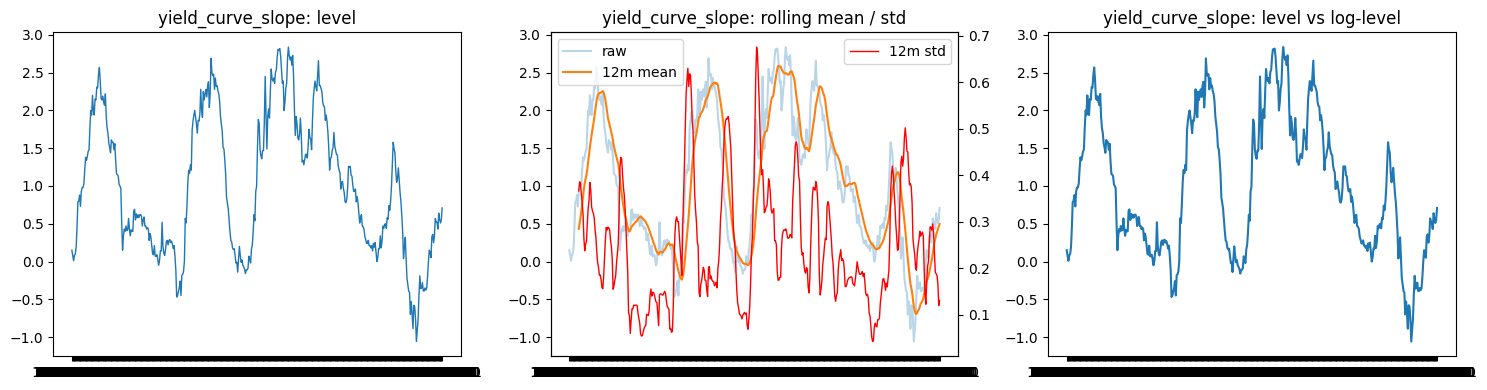

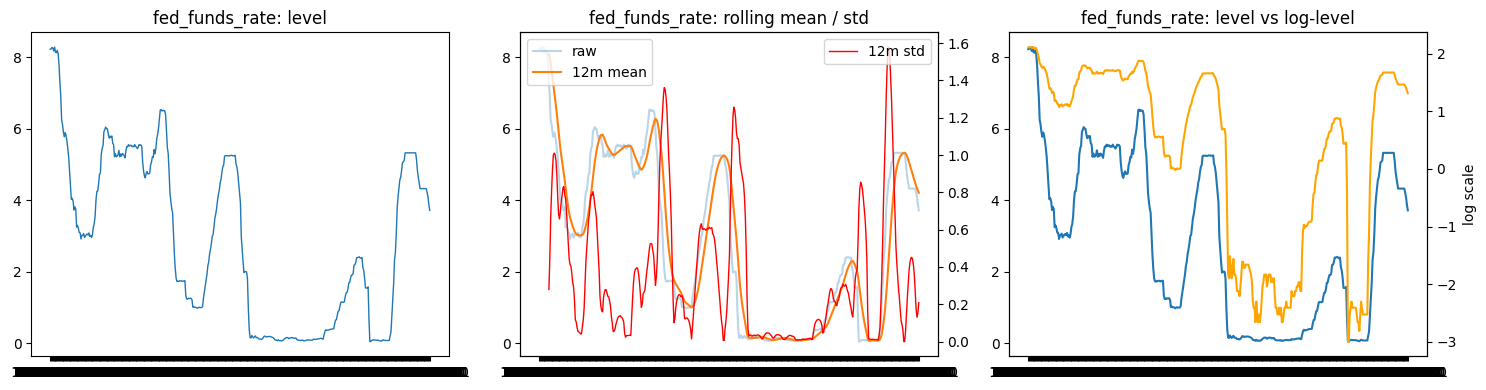

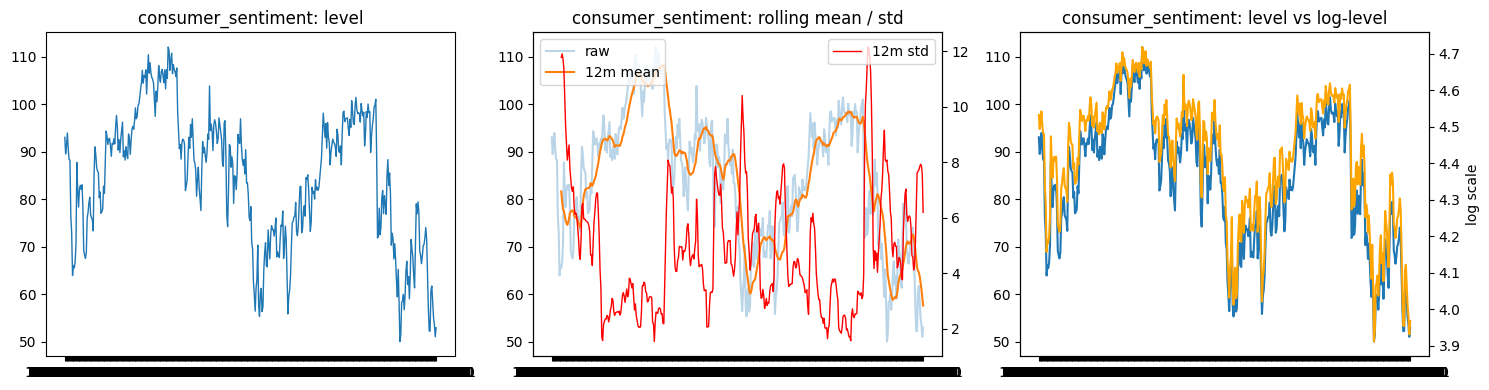

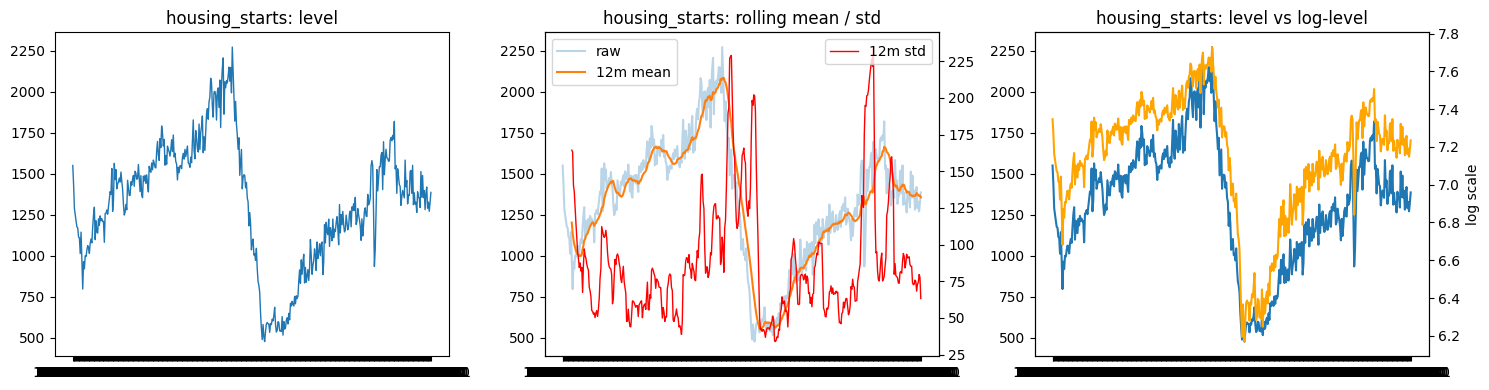

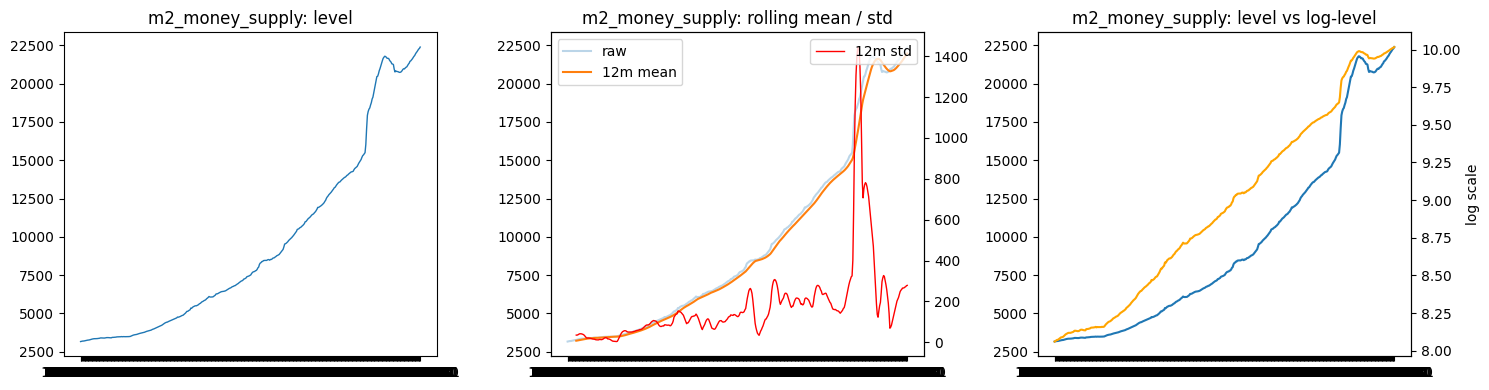

In [11]:
def diagnostic_plot(s: pd.Series, name: str, window: int = 12):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Panel (a): level
    axes[0].plot(s.index, s.values, lw=1)
    axes[0].set_title(f"{name}: level")

    # Panel (b): rolling 12-month mean and std
    rmean = s.rolling(window).mean()
    rstd  = s.rolling(window).std()
    ax2 = axes[1]
    ax2.plot(s.index, s.values, alpha=0.3, label="raw")
    ax2.plot(rmean.index, rmean.values, label=f"{window}m mean", lw=1.5)
    ax2_twin = ax2.twinx()
    ax2_twin.plot(rstd.index, rstd.values, color="red", label=f"{window}m std", lw=1.0)
    ax2.set_title(f"{name}: rolling mean / std")
    ax2.legend(loc="upper left")
    ax2_twin.legend(loc="upper right")

    # Panel (c): level vs log-level (only if strictly positive)
    axes[2].plot(s.index, s.values, label="level")
    if (s.dropna() > 0).all():
        ax3_twin = axes[2].twinx()
        ax3_twin.plot(s.index, np.log(s.values), color="orange", label="log(level)")
        ax3_twin.set_ylabel("log scale")
    axes[2].set_title(f"{name}: level vs log-level")

    plt.tight_layout()
    plt.show()


# Run for one example; loop in practice
for asset in df.columns:
    diagnostic_plot(df[asset].dropna(), asset)

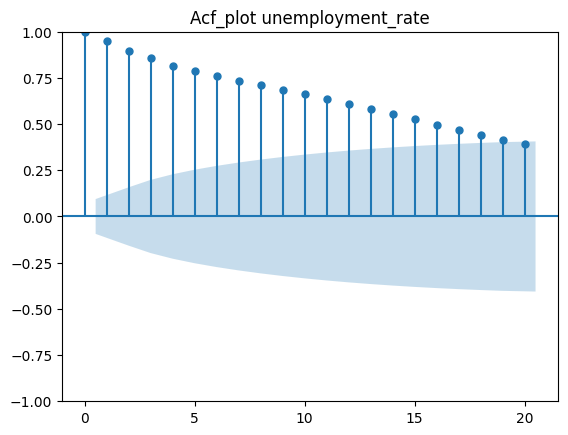

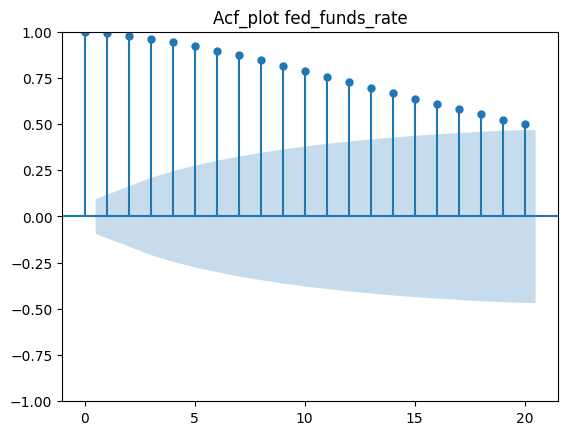

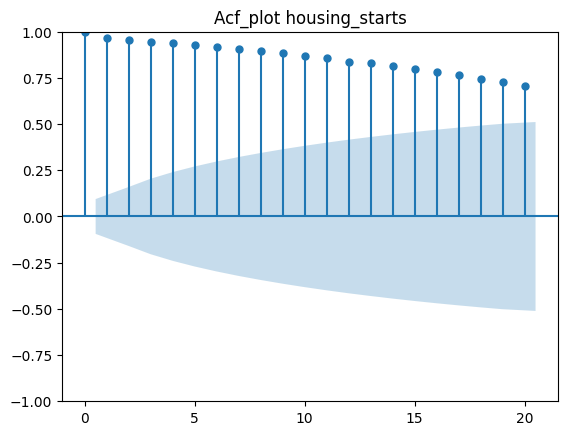

In [12]:
cols = ['unemployment_rate', 'fed_funds_rate', 'housing_starts']
for i in cols:
    plot_acf(df[i], lags=20, title=f'Acf_plot {i}')

In [13]:
TRANSFORM = {
    "industrial_production":   "dlog",
    "real_person_income":      "dlog",
    "unemployment_rate":       "diff",
    "initial_jobless_claims":  "dlog",
    "cpi":                     "dlog",
    "oil_price":               "dlog",
    "vix":                     "level",
    "credit_spread":           "level",
    "yield_curve_slope":       "level",
    "fed_funds_rate":          "diff",
    "consumer_sentiment":      "diff",
    "housing_starts":          "dlog",
    "m2_money_supply":         "dlog",
}

def transform(series: pd.Series, kind: str) -> pd.Series:
    if kind == "level":
        return series
    if kind == "diff":
        return series.diff()
    if kind == "dlog":
        return np.log(series).diff()
    raise ValueError(f"Unknown transform: {kind}")

# Apply
macro_stationary = pd.DataFrame(
    {col: transform(df[col], TRANSFORM[col]) for col in df.columns}
).dropna()

print(f"Transformed panel shape: {macro_stationary.shape}")
macro_stationary.head()

Transformed panel shape: (431, 13)


,industrial_production,real_person_income,unemployment_rate,initial_jobless_claims,cpi,oil_price,vix,credit_spread,yield_curve_slope,fed_funds_rate,consumer_sentiment,housing_starts,m2_money_supply
1990-02-28,0.009041,0.003557,-0.1,0.014389,0.003914,-0.051548,21.99,1.68,0.08,0.01,-3.5,-0.076342,0.003908
1990-03-31,0.004969,0.000873,-0.1,-0.011494,0.004677,-0.057786,19.73,1.58,0.01,0.04,1.8,-0.108691,0.003423
1990-04-30,-0.002623,0.006340,0.2,0.047964,0.002330,-0.094819,19.52,1.50,0.08,-0.02,2.6,-0.032324,0.003598
1990-05-31,0.003037,-0.001350,0.0,-0.011080,0.001550,-0.057286,17.37,1.71,0.10,-0.08,-3.3,-0.029270,-0.000312
1990-06-30,0.003386,0.001213,-0.2,0.013831,0.006178,-0.024335,15.50,1.79,0.19,0.11,-2.3,-0.029303,0.004085


In [14]:
trans_results = pd.DataFrame(
    {col: adf_kpss_verdict(macro_stationary[col]) for col in macro_stationary.columns}
).T.round(4)

print("\nPost-transformation stationarity tests")
print(trans_results)


Post-transformation stationarity tests
                           ADF p    KPSS p     verdict
industrial_production        0.0  0.074568  stationary
real_person_income           0.0       0.1  stationary
unemployment_rate            0.0       0.1  stationary
initial_jobless_claims       0.0       0.1  stationary
cpi                     0.001373       0.1  stationary
oil_price                    0.0       0.1  stationary
vix                     0.003015       0.1  stationary
credit_spread           0.004089  0.061956  stationary
yield_curve_slope       0.006535       0.1  stationary
fed_funds_rate          0.000225       0.1  stationary
consumer_sentiment           0.0       0.1  stationary
housing_starts               0.0       0.1  stationary
m2_money_supply         0.000944       0.1  stationary


In [15]:
comparison = pd.concat(
    [
        level_results.rename(columns={
            "ADF p": "ADF_level", "KPSS p": "KPSS_level", "verdict": "verdict_level"
        }),
        trans_results.rename(columns={
            "ADF p": "ADF_trans", "KPSS p": "KPSS_trans", "verdict": "verdict_trans"
        }),
    ],
    axis=1
)
print("\nLevel vs transformed comparison")
comparison


Level vs transformed comparison


,ADF_level,KPSS_level,verdict_level,ADF_trans,KPSS_trans,verdict_trans
industrial_production,0.260809,0.01,unit root,0.0,0.074568,stationary
real_person_income,0.990052,0.01,unit root,0.0,0.1,stationary
unemployment_rate,0.072481,0.1,inconclusive,0.0,0.1,stationary
initial_jobless_claims,0.0,0.1,stationary,0.0,0.1,stationary
cpi,0.997855,0.01,unit root,0.001373,0.1,stationary
oil_price,0.120168,0.01,unit root,0.0,0.1,stationary
vix,0.003496,0.1,stationary,0.003015,0.1,stationary
credit_spread,0.004411,0.059955,stationary,0.004089,0.061956,stationary
yield_curve_slope,0.007215,0.1,stationary,0.006535,0.1,stationary
fed_funds_rate,0.011643,0.01,inconclusive,0.000225,0.1,stationary


In [16]:
scaler = StandardScaler()
macro_scaled_array = scaler.fit_transform(macro_stationary)

macro_scaled = pd.DataFrame(
    macro_scaled_array,
    index=macro_stationary.index,
    columns=macro_stationary.columns,
)

# Sanity check: every column should now have mean ≈ 0 and std ≈ 1
print("Mean of each standardised variable (should be ~0):")
print(macro_scaled.mean().round(4))
print("\nStandard deviation of each standardised variable (should be ~1):")
print(macro_scaled.std().round(4))
print(f"\nFinal panel shape: {macro_scaled.shape}")
print(f"Date range: {macro_scaled.index.min()} to {macro_scaled.index.max()}")

Mean of each standardised variable (should be ~0):
industrial_production    -0.0
real_person_income       -0.0
unemployment_rate        -0.0
initial_jobless_claims   -0.0
cpi                       0.0
oil_price                 0.0
vix                       0.0
credit_spread            -0.0
yield_curve_slope         0.0
fed_funds_rate           -0.0
consumer_sentiment        0.0
housing_starts            0.0
m2_money_supply           0.0
dtype: float64

Standard deviation of each standardised variable (should be ~1):
industrial_production     1.0012
real_person_income        1.0012
unemployment_rate         1.0012
initial_jobless_claims    1.0012
cpi                       1.0012
oil_price                 1.0012
vix                       1.0012
credit_spread             1.0012
yield_curve_slope         1.0012
fed_funds_rate            1.0012
consumer_sentiment        1.0012
housing_starts            1.0012
m2_money_supply           1.0012
dtype: float64

Final panel shape: (431, 13)
Date

In [19]:
macro_scaled.to_csv(os.path.join(data_path, 'macro_clean.csv'))

<h1>Asset Data</h1>

In [20]:
price_raw = pd.read_csv(os.path.join(data_path, 'market_data.csv'), index_col="Date")

In [21]:
price_raw.head()

,index_fund,treasury_fund,gold_fund
Date,,,
1990-01-31,14.723949,0.628845,376.95
1990-02-28,14.911649,0.626791,383.64
1990-03-31,15.324143,0.624541,363.83
1990-04-30,14.940807,0.607535,363.33
1990-05-31,16.388983,0.634859,358.38


In [22]:
df1 = price_raw.copy()

In [23]:
df1 = df1.pct_change().dropna()

In [24]:
df1.head()

,index_fund,treasury_fund,gold_fund
Date,,,
1990-02-28,0.012748,-0.003267,0.017748
1990-03-31,0.027663,-0.003589,-0.051637
1990-04-30,-0.025015,-0.027230,-0.001374
1990-05-31,0.096928,0.044975,-0.013624
1990-06-30,-0.006555,0.022940,-0.003990


In [25]:
df1.to_csv(os.path.join(data_path, 'market_clean.csv'))